In [ ]:
# ==========================================
# Dataset QA Pipeline Quality Report - After balancing
# Project Echo
# Sprint 2
# ==========================================

## Dataset Overview

This dataset quality assessment was performed on the balanced data set from the  entire project data set hosted in Google Cloud
The dataset contains approximately 122 wildlife species represented across 10372 valid audio recordings. The purpose of including additional external recordings and edge-case files was to evaluate whether the validation pipeline could correctly identify different data conditions, including valid recordings, external data variations, and unsupported file formats.

The validation process focuses on assessing dataset readiness by identifying technical issues and reporting quality concerns. No recordings were automatically deleted or modified during the assessment.

## Environment Configuration and Dependency Check

This section verifies the execution environment before running the dataset quality assessment pipeline.

The code:
- Identifies the Python version and operating system.
- Checks the availability and versions of required Python packages.
- Confirms that the environment contains the necessary dependencies for audio processing, data analysis, and report generation.

Recording the environment details improves reproducibility by documenting the software versions used during dataset validation.

In [1]:
import sys
import platform
import importlib
from pathlib import Path
import zipfile

def package_version(package):
    try:
        return importlib.import_module(package).__version__
    except Exception:
        return "Not Installed"

print("="*60)
print("Dataset QA Pipeline Environment")
print("="*60)

print(f"Python Version: {sys.version.split()[0]}")
print(f"Platform: {platform.system()} {platform.release()}")

print()

packages = [
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "librosa",
    "soundfile",
    "scipy",
    "tqdm"
]

for package in packages:
    print(f"{package.capitalize()} Version: {package_version(package)}")

Dataset QA Pipeline Environment
Python Version: 3.13.5
Platform: Windows 10

Numpy Version: 2.1.3
Pandas Version: 2.3.2
Matplotlib Version: 3.10.0
Seaborn Version: 0.13.2
Librosa Version: 1.0.0
Soundfile Version: 0.14.0
Scipy Version: 1.16.1
Tqdm Version: 4.67.1


This section detects whether the pipeline is being executed inside Google Colab.

If Colab is detected:
- Required Python packages are installed automatically.
- Audio processing and visualisation dependencies are prepared before running the dataset quality pipeline.

In [ ]:
#run this for colab only
try:
    import google.colab

    IN_COLAB = True

except ImportError:

    IN_COLAB = False

print(f"Running in Google Colab: {IN_COLAB}")

if IN_COLAB:

    !pip -q install librosa soundfile seaborn tqdm

Running in Google Colab: True


**Configuration**

This section defines the paths, dataset structure, and validation settings used by the dataset quality assessment pipeline.

The configuration:
- Sets the project working directory.
- Defines the expected dataset ZIP file and extracted dataset folder names.
- Automatically extracts the dataset archive if the dataset folder is not already available.
- Defines supported audio formats for validation.
- Sets audio duration thresholds used during quality checks.
- Defines the output location and report generation options.

The dataset loading process is designed to support reproducible execution across environments by allowing either:
- an existing extracted dataset folder, or
- a compressed dataset ZIP file that can be automatically extracted.

In [47]:
# ==========================================
# CONFIGURATION
# ==========================================

 #change accordingly

 # Mount Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

# Project/dataset location in Google Drive
#PROJECT_ROOT = Path("/content/drive/MyDrive")
PROJECT_ROOT = Path.cwd()

# Dataset names , provide the required file names
DATASET_ZIP_NAME = "train.zip"
DATASET_FOLDER_NAME = "train_dataset"


# Dataset locations
ZIP_PATH = PROJECT_ROOT / DATASET_ZIP_NAME
DATASET_PATH = PROJECT_ROOT / DATASET_FOLDER_NAME


if not DATASET_PATH.exists():

    if not ZIP_PATH.exists():
        raise FileNotFoundError(
            f"No dataset found. Expected either:\n"
            f"1. Folder: {DATASET_PATH}\n"
            f"2. ZIP file: {ZIP_PATH}"
        )

    print("Extracting dataset ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATASET_PATH) #since theres no source seprate folder


SUPPORTED_AUDIO_EXTENSIONS = [
    ".wav",
    ".mp3",
    ".flac",
    ".ogg",
    ".m4a"
]

MIN_DURATION = 1

MAX_DURATION = 10

SAMPLE_RATE = 16000

SILENCE_THRESHOLD = 0.80      # 80% of frames with very low energy
ENERGY_THRESHOLD = 0.01       # Minimum mean RMS energy considered usable
VARIANCE_THRESHOLD = 0.05     # High variation in signal energy

REPORT_OUTPUT = PROJECT_ROOT / "train_reports"

GENERATE_CSV = True

GENERATE_TEXT_REPORT = True

Extracting dataset ZIP...


**Imports**

Import required libraries

In [3]:
import os
import re
import json
import hashlib
import warnings

import librosa
import soundfile as sf
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm


## **Data set discovery and manifest builder**

This section defines the dataset scanning component used to create an initial dataset manifest.

The scanner:
- Recursively searches the dataset directory and records all files.
- Captures key metadata including file name, path, extension, and file size.
- Checks whether the dataset follows the expected folder structure: dataset/
source/
species/
audio_file

- Identifies the dataset source and species labels from the directory structure.
- Flags inconsistent folder depths or missing source/species labels without deleting any records.

The output of this stage is a dataset manifest DataFrame that is used by later validation steps for audio quality checks, statistics generation, and reporting.

The source-aware structure allows the same pipeline to support multiple datasets (for example, GCP, iNaturalist, or ALA) without changing the validation logic.

Updated in this balanced checking part since the source is already known 

In [48]:
class DatasetScanner:

    def __init__(self, dataset_path,source=None):
        self.dataset_path = Path(dataset_path)
        self.source = source


    def scan_files(self):
        """
        Scan every file in dataset.
        """

        records = []

        for file in self.dataset_path.rglob("*"):

            if file.is_file():

                relative = file.relative_to(self.dataset_path)

                records.append({

                    "file_name": file.name,

                    "absolute_path": str(file),

                    "relative_path": str(relative).replace("\\",
"/"),

                    "extension": file.suffix.lower(),

                    "size_bytes": file.stat().st_size

                })


        return pd.DataFrame(records)

    def check_paths(self, df):

        """
    Check for inconsistent folder structures.
    Expected format:
        dataset/source/species/audio_file
    Also checks whether all files have a consistent folder depth.
    """

        depths = []
        status = []

      # Count folder depth for every file
        for path in df["relative_path"]:
            depths.append(len(Path(path).parts))

      # Most common folder depth
        expected_depth = max(set(depths), key=depths.count)

      # Validate each path
        for path, depth in zip(df["relative_path"], depths):
            parts = Path(path).parts

            if len(parts) < 3:
                status.append("Missing source or species folder")

            elif parts[0] == "":
                status.append("Invalid species folder")

            elif depth != expected_depth:
                status.append(f"Inconsistent depth ({depth} levels)")

            else:
                status.append("OK")
        df["path_status"] = status

        return df

    def detect_species(self, df):
        """
        Expected structure:

        dataset/
            source/
                species/
                    audio_file

        Example:

        datasets/
            gcp/
                bird_001/
                    audio.wav

        Output:
            source = gcp
            species = bird_001
        """

        sources = []
        species = []

        for path in df["relative_path"]:

            parts = Path(path).parts

            if len(parts) >= 2:
                # species/file
                species.append(parts[-2])
                if self.source is not None:
                    sources.append(self.source)
                else:
                    sources.append("unknown")
            else:
                sources.append(self.source if self.source else "unknown")
                species.append("unknown")


        df["source"] = sources
        df["species"] = species

        return df



scanner = DatasetScanner(DATASET_PATH,source="post_balanced")


manifest = scanner.scan_files()

manifest = scanner.detect_species(manifest)


print("Files found:",len(manifest))

manifest.head()

Files found: 6258


,file_name,absolute_path,relative_path,extension,size_bytes,source,species
0,project_echo_bucket_1__region_17.750-19.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa
1,project_echo_bucket_1__region_72.650-74.650.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa
2,project_echo_bucket_1__region_75.750-77.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,194860,post_balanced,acanthiza chrysorrhoa
3,project_echo_bucket_2__region_11.750-13.750.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,16945,post_balanced,acanthiza chrysorrhoa
4,project_echo_bucket_2__region_12.800-14.800.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,33261,post_balanced,acanthiza chrysorrhoa


In [49]:
# ==========================================
# SOURCE AND SPECIES COUNTS
# ==========================================

source_species_counts = (
    manifest
    .groupby(["source", "species"])
    .size()
    .reset_index(name="sample_count")
)


print(source_species_counts)



           source                species  sample_count
0   post_balanced  acanthiza chrysorrhoa            38
1   post_balanced      acanthiza lineata            36
2   post_balanced         acanthiza nana           150
3   post_balanced      acanthiza pusilla           150
4   post_balanced   acanthiza reguloides           150
..            ...                    ...           ...
74  post_balanced             sus scrofa            48
75  post_balanced    uperoleia altissima            78
76  post_balanced       uperoleia mimula            54
77  post_balanced         vanellus miles            66
78  post_balanced          vulpes vulpes           118

[79 rows x 3 columns]


## **Structure validation**

This section standardises species labels to improve consistency during dataset analysis and reporting.

The normalisation process:
- Converts labels to lowercase.
- Removes leading and trailing whitespace.
- Replaces special characters and spaces with underscores.
- Removes repeated underscores.

This ensures that the same species is represented consistently even if the original folder names contain different formatting styles.

The cleaned `species_label` field is used for:
- Species-level sample counts.
- Source/species statistics.
- Dataset quality reports.
- Downstream analysis.

In [50]:
# ==========================================
# LABEL NORMALISATION
# ==========================================
def normalise_label(name):

    name=str(name).lower().strip()

    name=re.sub(
        r"[^a-z0-9]+",
        "_",
        name
    )

    name=re.sub(
        r"_+",
        "_",
        name
    )

    return name.strip("_")



manifest["species_label"] = (
    manifest["species"]
    .apply(normalise_label)
)


manifest.head()

,file_name,absolute_path,relative_path,extension,size_bytes,source,species,species_label
0,project_echo_bucket_1__region_17.750-19.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa
1,project_echo_bucket_1__region_72.650-74.650.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa
2,project_echo_bucket_1__region_75.750-77.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,194860,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa
3,project_echo_bucket_2__region_11.750-13.750.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,16945,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa
4,project_echo_bucket_2__region_12.800-14.800.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,33261,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa


This section performs automated checks on the dataset structure and file metadata.

The validation checks include:
- **Empty files:** Identifies files with zero size that may indicate incomplete or corrupted data.
- **Missing species labels:** Detects samples where species information could not be extracted from the folder structure.
- **Unsupported file formats:** Flags files that do not match the supported audio extensions defined in the configuration.

The function generates a structure validation report summarising the number of issues detected for each check.

These checks are performed for reporting purposes only. Records are not automatically removed, which preserves the original dataset and follows the Sprint 1 requirement of avoiding destructive cleaning.

In [51]:
# ==========================================
# STRUCTURE VALIDATION
# ==========================================
def validate_structure(df):

    results=[]


    # Empty files

    empty_files=df[
        df["size_bytes"]==0
    ]


    results.append({

        "check":
        "Empty files",

        "count":
        len(empty_files)

    })


    # Missing labels

    missing_labels=df[
        df["species_label"]
        .isin(["unknown",""])
    ]


    results.append({

        "check":
        "Missing species labels",

        "count":
        len(missing_labels)

    })


    # Unsupported files

    unsupported=df[
        ~df.extension.isin(
            SUPPORTED_AUDIO_EXTENSIONS
        )
    ]


    results.append({

        "check":
        "Unsupported extensions",

        "count":
        len(unsupported)

    })


    return pd.DataFrame(results)



structure_report = validate_structure(manifest)


structure_report

,check,count
0,Empty files,0
1,Missing species labels,0
2,Unsupported extensions,0


## **Duplicate records check**

This section performs automated duplicate detection on the dataset using both record metadata and the actual contents of each audio file.

The duplicate checks include:

**Metadata-based duplicates**: Identifies records with matching species labels, sources, and filenames, which may indicate repeated records within the dataset.

**Exact file duplicates**: Calculates a SHA-256 hash for each valid audio file and identifies files with identical contents, even when their filenames or metadata differ.

The process generates separate results for metadata-based and exact file duplicates, allowing potential duplication issues to be reviewed and investigated.

These checks are performed for reporting and quality-control purposes only. Duplicate records are not automatically removed, which preserves the original dataset and follows the Sprint 1 requirement of avoiding destructive cleaning.

In [52]:
# ==========================================
# LEVEL 1 — RECORD / METADATA DUPLICATES
# ==========================================

# Check for duplicate records based on metadata.
# Filename is included because repeated filenames can indicate
# duplicated records within the dataset.

duplicate_candidates = manifest[
    (manifest["size_bytes"] > 0) &
    (manifest["extension"].isin(SUPPORTED_AUDIO_EXTENSIONS))
].copy()

metadata_duplicate_columns = [
    "species_label",
    "source",
    "file_name"
]


metadata_duplicates = duplicate_candidates[
    duplicate_candidates.duplicated(
        subset=metadata_duplicate_columns,
        keep=False
    )
].copy()


metadata_duplicates = metadata_duplicates.sort_values(
    metadata_duplicate_columns
)


print(
    f"Metadata duplicate records found: "
    f"{len(metadata_duplicates)}"
)


# ==========================================
# LEVEL 2 — EXACT FILE DUPLICATES
# ==========================================

def calculate_sha256(path):

    sha256 = hashlib.sha256()

    with open(path, "rb") as f:

        for chunk in iter(
            lambda: f.read(1024 * 1024),
            b""
        ):
            sha256.update(chunk)

    return sha256.hexdigest()


duplicate_candidates["sha256"] = (
    duplicate_candidates["absolute_path"]
    .apply(calculate_sha256)
)


file_duplicates = duplicate_candidates[
    duplicate_candidates.duplicated(
        subset=["sha256"],
        keep=False
    )
].copy()

file_duplicates = file_duplicates.sort_values(
    "sha256"
)


print(
    f"Exact file duplicates found: "
    f"{len(file_duplicates)}"
)

Metadata duplicate records found: 0
Exact file duplicates found: 104


In [53]:
# ==========================================
# DUPLICATE SUMMARY
# ==========================================

duplicate_summary = pd.DataFrame({
    "check": [
        "metadata_records",
        "exact_file_hash"
    ],

    "duplicate_records": [
        len(metadata_duplicates),
        len(file_duplicates)
    ],

    "status": [
        "duplicates_found"
        if len(metadata_duplicates) > 0
        else "no_duplicates_found",

        "duplicates_found"
        if len(file_duplicates) > 0
        else "no_duplicates_found"
    ]
})


duplicate_summary

,check,duplicate_records,status
0,metadata_records,0,no_duplicates_found
1,exact_file_hash,104,duplicates_found


## **Audio quality validation**

This section extends the dataset manifest with validation results rather than generating separate reports only.

The validation process includes:

- **Format validation:** Checks whether each file extension is supported by the pipeline and stores the result directly in the manifest using the `format_status` column.
- **Audio validation:** Attempts to load each audio file and extracts technical properties including:
  - Readability status.
  - Duration.
  - Sample rate.
  - Number of channels.
  - Audio quality issues such as invalid duration or unreadable files.

By adding these validation results directly to the manifest, every audio sample retains its original metadata together with its quality assessment results. This allows later reports to be generated from a single validated dataset table without modifying or removing records.

In [54]:
#add the unsupported extension to the manifest
def validate_format(extension):

    if extension in SUPPORTED_AUDIO_EXTENSIONS:
        return "OK"

    else:
        return "unsupported_format"

manifest["format_status"] = (
    manifest["extension"]
    .apply(validate_format)
)

In [55]:
# ==========================================
# AUDIO VALIDATION
# ==========================================


def validate_audio(path):

    result={

        "readable":False,

        "duration":None,

        "sample_rate":None,

        "channels":None,

        "issue":""

    }


    try:

        audio,sr = librosa.load(
            path,
            sr=None,
            mono=False
        )


        result["readable"]=True

        result["sample_rate"]=sr


        if audio.ndim==1:
            channels=1

        else:
            channels=audio.shape[0]


        result["channels"]=channels


        duration=librosa.get_duration(
            y=audio,
            sr=sr
        )


        result["duration"]=round(
            duration,
            3
        )


    except Exception as e:

        result["issue"]="unreadable"



    return result

In [56]:
# Run audio validation
audio_checks = (
    manifest["absolute_path"]
    .apply(validate_audio)
)

audio_checks = pd.DataFrame(audio_checks.tolist())

manifest = pd.concat(
    [manifest, audio_checks],
    axis=1
)

manifest.head()

,file_name,absolute_path,relative_path,extension,size_bytes,source,species,species_label,format_status,readable,duration,sample_rate,channels,issue
0,project_echo_bucket_1__region_17.750-19.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa,OK,True,2.052,44100,1,
1,project_echo_bucket_1__region_72.650-74.650.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,181036,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa,OK,True,2.052,44100,1,
2,project_echo_bucket_1__region_75.750-77.750.wav,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.wav,194860,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa,OK,True,2.029,48000,1,
3,project_echo_bucket_2__region_11.750-13.750.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,16945,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa,OK,True,2.052,44100,1,
4,project_echo_bucket_2__region_12.800-14.800.mp3,C:\Users\ASUS\Documents\train_dataset\train\ac...,train/acanthiza chrysorrhoa/project_echo_bucke...,.mp3,33261,post_balanced,acanthiza chrysorrhoa,acanthiza_chrysorrhoa,OK,True,2.029,48000,2,


In [57]:
print(manifest)

                                            file_name  \
0     project_echo_bucket_1__region_17.750-19.750.wav   
1     project_echo_bucket_1__region_72.650-74.650.wav   
2     project_echo_bucket_1__region_75.750-77.750.wav   
3     project_echo_bucket_2__region_11.750-13.750.mp3   
4     project_echo_bucket_2__region_12.800-14.800.mp3   
...                                               ...   
6253  project_echo_bucket_3__region_81.450-83.450.mp3   
6254  project_echo_bucket_3__region_88.910-90.509.mp3   
6255  project_echo_bucket_3__region_89.210-91.209.mp3   
6256  project_echo_bucket_3__region_96.900-97.950.mp3   
6257  project_echo_bucket_3__region_98.750-99.800.mp3   

                                          absolute_path  \
0     C:\Users\ASUS\Documents\train_dataset\train\ac...   
1     C:\Users\ASUS\Documents\train_dataset\train\ac...   
2     C:\Users\ASUS\Documents\train_dataset\train\ac...   
3     C:\Users\ASUS\Documents\train_dataset\train\ac...   
4     C:\Users\ASUS\

## Duration Distribution Analysis

This section performs an analysis of the recording durations in the dataset to understand their overall distribution and identify potential duration outliers.

The analysis includes:
- **Valid duration values:** Uses only readable records with available duration information, excluding missing duration values from the analysis.
- **Five-number summary:** Calculates the minimum, first quartile (Q1), median, third quartile (Q3), and maximum recording duration.
- **Interquartile range (IQR):** Calculates the spread of the middle 50% of recording durations using the difference between Q3 and Q1.
- **Outlier boundaries:** Calculates lower and upper boundaries using the standard 1.5 × IQR rule to identify recordings that may have unusually short or long durations.
- **Histogram:** Visualises the distribution of recording durations across 50 bins, with the median, Q1, and Q3 marked to make the distribution and spread easier to interpret.

The resulting five-number summary and IQR boundaries provide numerical information about the duration distribution, while the histogram provides a visual representation of how recording lengths are distributed across the dataset.

These checks are performed for dataset analysis and quality-control purposes only. Recordings are not automatically removed based on their duration, which preserves the original dataset and follows the Sprint 1 requirement of avoiding destructive cleaning.

 minimum  Q1  median    Q3  maximum   IQR  lower_outlier_boundary  upper_outlier_boundary
     1.0 1.9   2.029 2.052   99.504 0.152                   1.672                    2.28


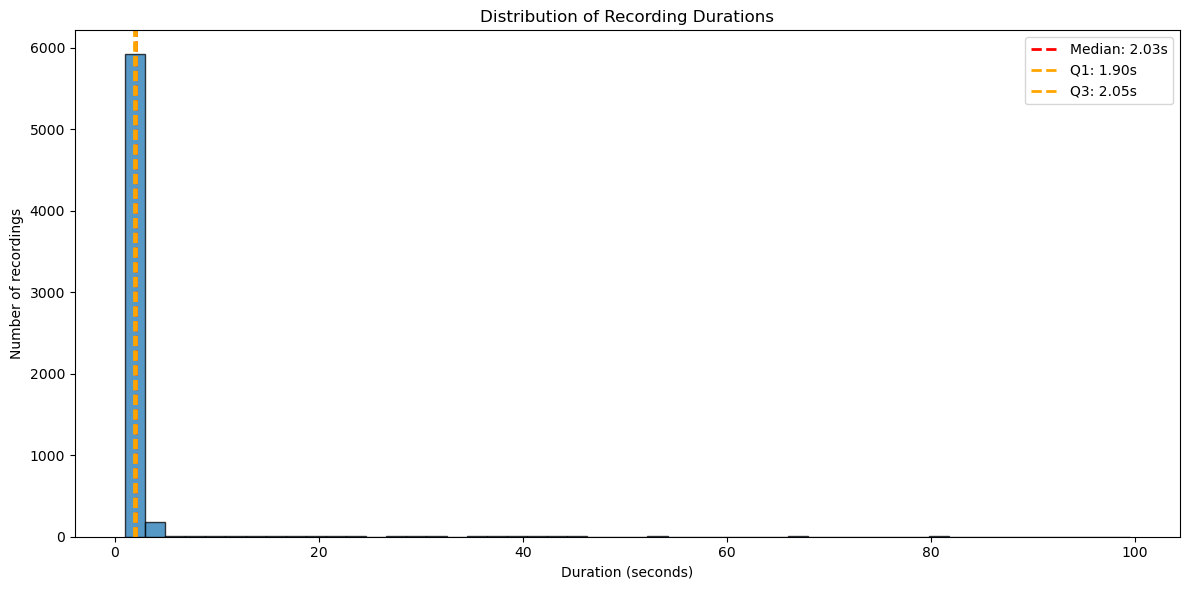

In [58]:
# ==========================================
# DURATION DISTRIBUTION ANALYSIS
# ==========================================

import matplotlib.pyplot as plt


duration_data = manifest.loc[
    manifest["readable"] == True,
    "duration"
].dropna()


# Five-number summary

duration_summary = pd.DataFrame({
    "minimum": [duration_data.min()],
    "Q1": [duration_data.quantile(0.25)],
    "median": [duration_data.median()],
    "Q3": [duration_data.quantile(0.75)],
    "maximum": [duration_data.max()]
})


# IQR

Q1 = duration_data.quantile(0.25)
Q3 = duration_data.quantile(0.75)

IQR = Q3 - Q1

duration_summary["IQR"] = IQR

duration_summary["lower_outlier_boundary"] = (
    Q1 - 1.5 * IQR
)

duration_summary["upper_outlier_boundary"] = (
    Q3 + 1.5 * IQR
)


print(duration_summary.to_string(index=False))


# ==========================================
# HISTOGRAM
# ==========================================

plt.figure(figsize=(12, 6))

plt.hist(
    duration_data,
    bins=50,
    edgecolor="black",
    alpha=0.75
)

plt.axvline(
    duration_data.median(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Median: {duration_data.median():.2f}s"
)

plt.axvline(
    Q1,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Q1: {Q1:.2f}s"
)

plt.axvline(
    Q3,
    color="orange",
    linestyle="--",
    linewidth=2,
    label=f"Q3: {Q3:.2f}s"
)

plt.xlabel("Duration (seconds)")
plt.ylabel("Number of recordings")
plt.title("Distribution of Recording Durations")

plt.legend()
plt.tight_layout()

plt.show()

In [59]:
# ==========================================
# APPLY DURATION VALIDATION
# ==========================================

manifest.loc[
    manifest["duration"] < MIN_DURATION,
    "issue"
] = "too_short"


manifest.loc[
    manifest["duration"] > MAX_DURATION,
    "issue"
] = "too_long"


manifest.loc[
    (
        manifest["readable"] == True
    )
    &
    (
        manifest["duration"] >= MIN_DURATION
    )
    &
    (
        manifest["duration"] <= MAX_DURATION
    ),
    "issue"
] = " "

print(manifest)

                                            file_name  \
0     project_echo_bucket_1__region_17.750-19.750.wav   
1     project_echo_bucket_1__region_72.650-74.650.wav   
2     project_echo_bucket_1__region_75.750-77.750.wav   
3     project_echo_bucket_2__region_11.750-13.750.mp3   
4     project_echo_bucket_2__region_12.800-14.800.mp3   
...                                               ...   
6253  project_echo_bucket_3__region_81.450-83.450.mp3   
6254  project_echo_bucket_3__region_88.910-90.509.mp3   
6255  project_echo_bucket_3__region_89.210-91.209.mp3   
6256  project_echo_bucket_3__region_96.900-97.950.mp3   
6257  project_echo_bucket_3__region_98.750-99.800.mp3   

                                          absolute_path  \
0     C:\Users\ASUS\Documents\train_dataset\train\ac...   
1     C:\Users\ASUS\Documents\train_dataset\train\ac...   
2     C:\Users\ASUS\Documents\train_dataset\train\ac...   
3     C:\Users\ASUS\Documents\train_dataset\train\ac...   
4     C:\Users\ASUS\

## Species Duration Report

This section analyses recording duration issues across individual species to determine whether certain species contain a higher proportion of unusually short or long recordings.

The analysis includes:
- **Total readable recordings:** Counts the number of readable recordings available for each species.
- **Too-short recordings:** Counts recordings identified as being below the defined minimum duration threshold.
- **Too-long recordings:** Counts recordings identified as exceeding the defined maximum duration threshold.
- **Total duration issues:** Combines the number of too-short and too-long recordings for each species.
- **Duration issue percentage:** Calculates the percentage of readable recordings for each species that have a duration issue.
- **Species ranking:** Sorts the report by duration issue percentage in descending order, placing species with the highest proportion of duration issues at the top.

The resulting report provides a species-level view of recording duration quality, making it easier to identify species that may require further investigation due to a high proportion of unusually short or long recordings.

These results are used for dataset analysis and quality-control reporting only. Recordings are not automatically removed based on their duration issues, preserving the original dataset and following the Sprint 1 requirement of avoiding destructive cleaning.

In [60]:
# ==========================================
# SPECIES DURATION REPORT
# ==========================================

species_duration_report = (
    manifest[
        manifest["readable"] == True
    ]
    .groupby("species")
    .agg(
        total_readable=("issue", "size"),

        too_short=(
            "issue",
            lambda x: (x == "too_short").sum()
        ),

        too_long=(
            "issue",
            lambda x: (x == "too_long").sum()
        )
    )
    .reset_index()
)


species_duration_report["total_duration_issues"] = (
    species_duration_report["too_short"] +
    species_duration_report["too_long"]
)


species_duration_report["duration_issue_pct"] = (
    species_duration_report["total_duration_issues"]
    / species_duration_report["total_readable"]
    * 100
)


species_duration_report["duration_issue_pct"] = (
    species_duration_report["duration_issue_pct"]
    .round(2)
)


species_duration_report = (
    species_duration_report
    .sort_values(
        "duration_issue_pct",
        ascending=False
    )
)

## **Data set statistics**

This section generates summary statistics describing the distribution of the dataset.

The analysis includes:

- **Species counts:** Calculates the number of audio samples available for each species label.
- **Source counts:** Calculates the number of samples contributed by each dataset source.

These statistics provide an overview of dataset composition and help identify:
- Species imbalance.
- Dominant or underrepresented sources.
- The overall distribution of available samples.

The counts are generated from the validated manifest, ensuring that all statistics are linked back to the original file metadata and quality assessment results.

In [61]:
# ==========================================
# DATASET STATISTICS
# ==========================================

# Supported audio files only
audio_manifest = manifest[
    manifest["relative_path"]
    .str.lower()
    .str.endswith(tuple(SUPPORTED_AUDIO_EXTENSIONS))
].copy()


# ==========================================
# SPECIES COUNTS
# ==========================================

species_counts = (
    audio_manifest
    .groupby("species_label")
    .size()
    .reset_index(
        name="file_count"
    )
)

species_counts = species_counts.sort_values(
    "file_count",
    ascending=False
)


# ==========================================
# SOURCE COUNTS
# ==========================================

source_counts = (
    audio_manifest
    .groupby("source")
    .size()
    .reset_index(
        name="file_count"
    )
)

source_counts = source_counts.sort_values(
    "file_count",
    ascending=False
)

## Generate invliad record list

Get all the invlaid records as a seprarte output for the quality pipeline

In [62]:
# Create invalid records report
invalid_records = manifest[
    (manifest["readable"] == False) |
    (manifest["format_status"] != "OK") |
    (manifest["issue"].notna() & (manifest["issue"].astype(str).str.strip() != ""))
].copy()

In [63]:
print("Total records in manifest:", len(manifest))
print("Total invalid records:", len(invalid_records))

Total records in manifest: 6258
Total invalid records: 129


Final summary report  with all the chekcs

In [64]:
def generate_summary():

    summary={

        "total_files":
        len(manifest),


        "species_count":
        manifest.species_label.nunique(),

        "source_count":
        manifest.source.nunique(),


        "unreadable_audio":
        sum(
            manifest.issue=="unreadable"
        ),


        "missing_labels":
        sum(
            manifest.species_label=="unknown"
        ),


        "empty_files":
        sum(
            manifest.size_bytes==0
        )

    }


    return pd.DataFrame(
        [summary]
    )


summary_report=generate_summary()


summary_report

,total_files,species_count,source_count,unreadable_audio,missing_labels,empty_files
0,6258,79,1,0,0,0


## Acoustic Complexity Analysis

This section adds an additional acoustic analysis layer to evaluate general audio characteristics across different recordings.

The analysis generates quality indicators rather than performing species classification. The extracted features include:

- **Silence ratio:** Measures the proportion of the recording with very low energy, helping identify recordings dominated by silence.
- **Mean energy:** Represents the overall signal strength of the recording.
- **Energy variance:** Measures changes in signal intensity and identifies recordings with high variability.
- **Spectral centroid:** Estimates the frequency distribution of the audio signal and provides an indicator of acoustic characteristics.

A quality flag is assigned based on simple threshold rules:
- `HIGH_SILENCE` — recording contains a high proportion of silence.
- `LOW_SIGNAL` — recording has very low energy.
- `HIGH_VARIABILITY` — recording has large energy fluctuations.
- `GOOD` — recording passes the quality checks.

Any analysis errors are recorded in the output using the `error` field without stopping the pipeline. This allows problematic files to be identified while preserving all dataset records.

The output can be combined with source and species labels from the manifest to compare acoustic quality across different recordings and datasets.

In [65]:
#add this analysis too as a addition - acoustic complexity with different sounds
def analyse_acoustic_complexity(
    file_path,
    sample_rate=SAMPLE_RATE
):
    """
    Analyse environmental audio complexity.
    Only generates quality indicators.
    """

    result = {
        "file_path": file_path,
        "silence_ratio": None,
        "mean_energy": None,
        "energy_variance": None,
        "spectral_centroid": None,
        "quality_flag": None,
        "error": None
    }


    try:

        audio, sr = librosa.load(
            file_path,
            sr=sample_rate,
            mono=True
        )


        # RMS energy
        rms = librosa.feature.rms(
            y=audio
        )[0]


        silence_ratio = np.mean(
            rms < ENERGY_THRESHOLD
        )


        mean_energy = np.mean(rms)

        energy_variance = np.var(rms)


        spectral_centroid = np.mean(
            librosa.feature.spectral_centroid(
                y=audio,
                sr=sample_rate
            )
        )


        # Quality rules
        if silence_ratio > SILENCE_THRESHOLD:

            flag = "HIGH_SILENCE"


        elif mean_energy < ENERGY_THRESHOLD:

            flag = "LOW_SIGNAL"


        elif energy_variance >VARIANCE_THRESHOLD:

            flag = "HIGH_VARIABILITY"


        else:

            flag = "GOOD"


        result.update({

            "silence_ratio":
                round(float(silence_ratio),4),

            "mean_energy":
                round(float(mean_energy),6),

            "energy_variance":
                round(float(energy_variance),6),

            "spectral_centroid":
                round(float(spectral_centroid),3),

            "quality_flag":
                flag
        })


    except Exception as e:
        # Record audio analysis errors without stopping the pipeline.
        result["quality_flag"] = "ERROR"
        result["error"] = str(e)


    return result

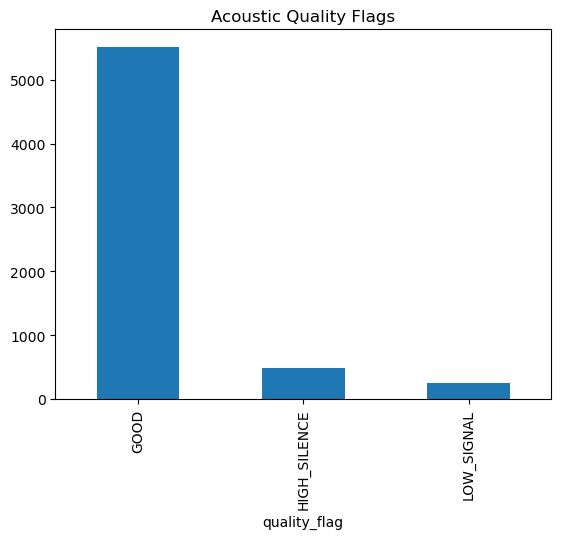

In [66]:
acoustic_results = []


for _, row in manifest.iterrows():

    result = analyse_acoustic_complexity(
        row["absolute_path"]
    )

    result["species"] = row["species_label"]

    result["source"] = row["source"]

    acoustic_results.append(result)


acoustic_report = pd.DataFrame(
    acoustic_results
)

acoustic_report.head()

acoustic_report["quality_flag"].value_counts().plot(
    kind="bar",
    title="Acoustic Quality Flags"
)

plt.show()

In [67]:
print(acoustic_report)

                                              file_path  silence_ratio  \
0     C:\Users\ASUS\Documents\train_dataset\train\ac...         0.0000   
1     C:\Users\ASUS\Documents\train_dataset\train\ac...         0.0462   
2     C:\Users\ASUS\Documents\train_dataset\train\ac...         0.0000   
3     C:\Users\ASUS\Documents\train_dataset\train\ac...         0.1538   
4     C:\Users\ASUS\Documents\train_dataset\train\ac...         0.3750   
...                                                 ...            ...   
6253  C:\Users\ASUS\Documents\train_dataset\train\vu...         0.0000   
6254  C:\Users\ASUS\Documents\train_dataset\train\vu...         0.2000   
6255  C:\Users\ASUS\Documents\train_dataset\train\vu...         0.3175   
6256  C:\Users\ASUS\Documents\train_dataset\train\vu...         0.3333   
6257  C:\Users\ASUS\Documents\train_dataset\train\vu...         0.0000   

      mean_energy  energy_variance  spectral_centroid quality_flag error  \
0        0.035311         0.000122 

## Report Generation and Export

This section saves all generated dataset quality reports to the configured output directory.

The exported reports include:

- **Dataset manifest:** Complete file-level metadata table containing paths, labels, formats, and validation results.
- **Structure report:** Summary of structural issues such as missing labels, empty files, and unsupported formats.
- **Species counts:** Number of samples available for each species label.
- **Source-species counts:** Distribution of samples across dataset sources and species combinations.
- **Acoustic complexity report:** Additional audio quality indicators including energy, silence, and spectral features.

Reports are saved as CSV files to allow easy inspection, sharing, and further analysis.

The original dataset is not modified or cleaned automatically. Instead, all quality findings are preserved as reports to support review and future processing decisions.

In [68]:
REPORT_PATH = Path(REPORT_OUTPUT)

REPORT_PATH.mkdir(
    exist_ok=True
)

manifest.to_csv(
    REPORT_PATH /
    "dataset_manifest.csv",
    index=False
)


structure_report.to_csv(
    REPORT_PATH /
    "structure_report.csv",
    index=False
)

metadata_duplicates.to_csv(
    REPORT_OUTPUT / "metadata_duplicates.csv",
    index=False
)

file_duplicates.to_csv(
    REPORT_OUTPUT / "file_duplicates.csv",
    index=False
)

duplicate_summary.to_csv(
    REPORT_OUTPUT / "duplicate_summary.csv",
    index=False
)


species_counts.to_csv(
    REPORT_PATH /
    "species_counts.csv",
    index=False
)

source_species_counts.to_csv(
    REPORT_OUTPUT / "source_species_counts.csv",
    index=False
)

invalid_records.to_csv(
    REPORT_OUTPUT / "invalid_records.csv",
    index=False
)

species_duration_report.to_csv(
    REPORT_OUTPUT / "species_duration_report.csv",
    index=False
)

acoustic_report.to_csv(
    REPORT_OUTPUT / "acoustic_complexity_report.csv",
    index=False
)

## Recommended Dataset Cleaning Rules

The following recommendations are provided based on the validation and acoustic quality assessment results.  
During Sprint 1, no recordings are automatically deleted or modified. These rules are intended to support future dataset cleaning decisions while maintaining dataset traceability.

| Issue Identified | Recommended Action |
|---|---|
| Missing audio file | Verify the dataset source and restore the file where possible. If unavailable, mark the record as unusable. |
| Unreadable or corrupted audio | Attempt to recover or replace the recording. Investigate the cause before removing the record. |
| Missing species label | Recover labels from available metadata where possible. Records without reliable labels should be reviewed before supervised training. |
| Inconsistent file paths | Update dataset references or manifests so paths correctly match the stored audio files. |
| Unsupported audio format | Convert recordings to the required project format during preprocessing while preserving the original file. |
| Invalid duration | Review unusually short or long recordings to determine whether they contain useful species information. |
| Missing source information | Recover source details where possible to maintain dataset traceability. |

---

## Acoustic Quality Review Rules

The acoustic analysis stage provides additional information about recording conditions.  
Quality flags are used for review and do not automatically remove recordings.

| Quality Flag | Recommended Action |
|---|---|
| GOOD | Recording appears suitable for further processing and model evaluation. |
| HIGH_SILENCE | Review whether the recording contains sufficient acoustic information or excessive silent periods. |
| LOW_SIGNAL | Check whether weak animal calls are present. Consider excluding if the recording provides limited useful information. |
| HIGH_VARIABILITY | Review for unstable recording conditions, environmental noise, or sudden changes in signal level. |
| ERROR | Investigate the processing issue and rerun analysis after resolving the problem. |

---

## General Cleaning Principles

- Preserve original recordings and avoid destructive changes.
- Use validation reports (CSV files) as evidence before making cleaning decisions.
- Keep cleaning decisions separate from the validation process.
- Document any changes applied to the dataset.
- Re-run validation after cleaning to confirm dataset improvements.
- Maintain dataset reports to support reproducibility and future model development.

In [ ]:
#Sprint 2
#Raveesha Somawansa
#s225559348